<a href="https://colab.research.google.com/github/Karsuman4298/Deep-learning/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

100%|██████████| 68.8M/68.8M [00:00<00:00, 263MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4


In [ ]:
import os

# List the contents of the directory to find the actual CSV file(s)
files_in_dir = os.listdir(path)
print(f"Files in the dataset directory '{path}': {files_in_dir}")

# Assuming 'fashion-mnist_train.csv' is one of the files in the directory
# You might need to adjust the filename based on the output of os.listdir
csv_file_name = "fashion-mnist_train.csv"
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)

Files in the dataset directory '/root/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4': ['train-labels-idx1-ubyte', 'fashion-mnist_train.csv', 'train-images-idx3-ubyte', 't10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv']


In [ ]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


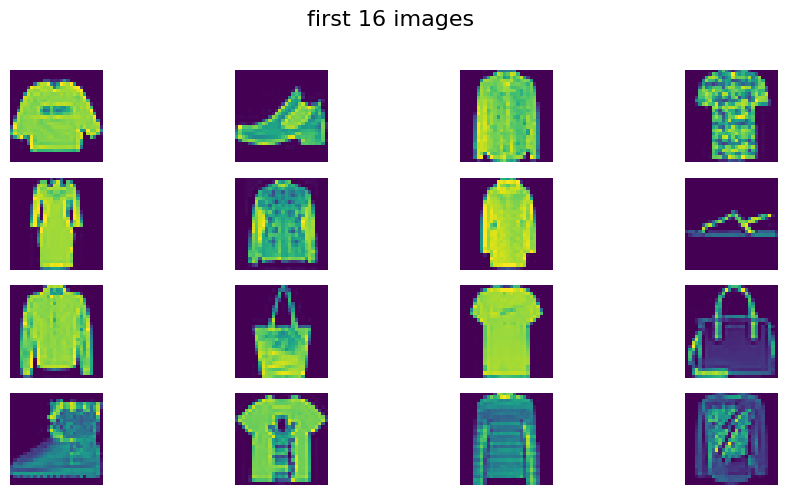

In [ ]:
fig,axes=plt.subplots(4,4,figsize=(10,5))
fig.suptitle("first 16 images ",fontsize=16)

for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [ ]:

X=df.iloc[:,1:].values
y=df.iloc[:,0].values


In [ ]:

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
#scaling the features
X_train=X_train/255.0
X_test=X_test/255.0

In [ ]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.00392157, ..., 0.14901961, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
class custom_dataset(Dataset):
  def __init__(self,x,y):
    self.x=torch.tensor(x.astype(np.float32).reshape(-1,1,28,28))
    self.y=torch.tensor(y,dtype=torch.long)

  def __len__(self):
    return len(self.x)

  def __getitem__(self, index):
     return self.x[index], self.y[index]

In [ ]:
train_dataset=custom_dataset(X_train,y_train)
test_dataset=custom_dataset(X_test,y_test)


In [ ]:
train_dataset.x.shape

torch.Size([48000, 1, 28, 28])

In [ ]:
len(train_dataset),len(test_dataset)

(48000, 12000)

In [42]:
# Build CNN
class CNN(nn.Module):
  def __init__(self,input_features,output_features):
    super(CNN, self).__init__()

    self.features=nn.Sequential(
        nn.Conv2d(input_features,32,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2,stride=2) ,

        nn.Conv2d(32,64,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2,stride=2) ,
    )

    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7,128),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(64,output_features)

    )

  def forward(self,x):
    x=self.features(x)
    x=self.classifier

    return x

In [ ]:
lr=0.01
epoch=100

In [43]:
model=CNN(1, num_classes)
model.to(device)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [44]:
from torch.optim import optimizer
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=lr,weight_decay=1e-4)